# 数学基础

本notebook涵盖深度学习所需的数学基础知识:
- 线性代数: 向量、矩阵运算和范数
- 微积分: 导数、梯度和链式法则
- 概率论: 随机变量、概率分布和统计推断

这些数学工具是理解深度学习算法的关键。

## 第一部分: 线性代数

### 1.1 标量、向量、矩阵和张量

线性代数为处理表格数据提供了数学工具。

In [1]:
# 让 matplotlib 绘图可以直接支持中文，安装一下下面这个包
!pip install -U matplotlib_cn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for matplotlib_cn: filename=matplotlib_cn-1.0.3-py3-none-any.whl size=5294689 sha256=7ca1a693afb69b59b8ad79486404afcda9a5f5ec7b66425ffd668775b655f52a
  Stored in directory: /root/.cache/pip/wheels/e5/21/2b/fd76757ba2067c87b6a33f78d89f62a46d936b341628985572
Successfully built matplotlib_cn


In [2]:
# 让 matplotlib 绘图支持中文
from matplotlib_cn import matplotlib_chinese

matplotlib_chinese.enable_matplotlib_chinese()


[matplotlib_cn] matplotlib enabled with Chinese font: SimHei 


In [3]:
import torch

**标量**: 单个数值

In [29]:
x = torch.tensor(3.0)
y = torch.tensor(2.0)

print("标量运算:")
print(f"x + y = {x + y}")
print(f"x - y = {x - y}")
print(f"x * y = {x * y}")
print(f"x / y = {x / y}")
print(f"x ** y = {x ** y}")

标量运算:
x + y = 5.0
x - y = 1.0
x * y = 6.0
x / y = 1.5
x ** y = 9.0


**向量**: 标量值组成的列表

In [5]:
x = torch.arange(4)
print("向量x:", x)
print("访问元素x[3]:", x[3])
print("向量长度:", len(x))
print("向量形状:", x.shape)

向量x: tensor([0, 1, 2, 3])
访问元素x[3]: tensor(3)
向量长度: 4
向量形状: torch.Size([4])


**矩阵**: 二维数组

In [6]:
A = torch.arange(20).reshape(5, 4)
print("矩阵A:")
print(A)
print("\n矩阵转置A.T:")
print(A.T)

矩阵A:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

矩阵转置A.T:
tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])


**对称矩阵**: $\mathbf{A} = \mathbf{A}^\top$

In [7]:
B = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
print("对称矩阵B:")
print(B)
print("\nB == B.T:")
print(B == B.T)

对称矩阵B:
tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

B == B.T:
tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])


### 1.2 张量运算

**Hadamard积(按元素乘法)**

In [8]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone()
print("A * B (Hadamard积):")
print(A * B)

A * B (Hadamard积):
tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])


**张量求和与均值**

In [9]:
print("A的形状:", A.shape)
print("A所有元素的和:", A.sum())
print("\n沿axis=0求和(按列):", A.sum(axis=0))
print("沿axis=1求和(按行):", A.sum(axis=1))
print("\n沿所有轴求和:", A.sum(axis=[0, 1]))

# 均值
print("\n均值:", A.mean())
print("沿axis=0的均值:", A.mean(axis=0))

A的形状: torch.Size([5, 4])
A所有元素的和: tensor(190.)

沿axis=0求和(按列): tensor([40., 45., 50., 55.])
沿axis=1求和(按行): tensor([ 6., 22., 38., 54., 70.])

沿所有轴求和: tensor(190.)

均值: tensor(9.5000)
沿axis=0的均值: tensor([ 8.,  9., 10., 11.])


**保持维度的求和**

In [10]:
sum_A = A.sum(axis=1, keepdims=True)
print("保持维度的求和:")
print(sum_A)
print("形状:", sum_A.shape)

# 利用广播进行归一化
print("\n归一化(每行和为1):")
print(A / sum_A)

保持维度的求和:
tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]])
形状: torch.Size([5, 1])

归一化(每行和为1):
tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])


**累积求和**

In [11]:
print("沿axis=0的累积和:")
print(A.cumsum(axis=0))

沿axis=0的累积和:
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.],
        [24., 28., 32., 36.],
        [40., 45., 50., 55.]])


### 1.3 点积、矩阵-向量积和矩阵乘法

**点积**: $\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^{d} x_i y_i$

In [12]:
x = torch.arange(4, dtype=torch.float32)
y = torch.ones(4, dtype=torch.float32)

print("向量x:", x)
print("向量y:", y)
print("点积:", torch.dot(x, y))

# 等价于按元素乘法后求和
print("等价计算:", torch.sum(x * y))

向量x: tensor([0., 1., 2., 3.])
向量y: tensor([1., 1., 1., 1.])
点积: tensor(6.)
等价计算: tensor(6.)


**矩阵-向量积**: $\mathbf{A}\mathbf{x}$

In [13]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
x = torch.arange(4, dtype=torch.float32)

print("矩阵A的形状:", A.shape)
print("向量x的形状:", x.shape)
print("\n矩阵-向量积 A @ x:")
print(torch.mv(A, x))
print("形状:", torch.mv(A, x).shape)

矩阵A的形状: torch.Size([5, 4])
向量x的形状: torch.Size([4])

矩阵-向量积 A @ x:
tensor([ 14.,  38.,  62.,  86., 110.])
形状: torch.Size([5])


**矩阵乘法**: $\mathbf{C} = \mathbf{A}\mathbf{B}$

In [14]:
B = torch.ones(4, 3)
print("矩阵乘法 A @ B:")
print(torch.mm(A, B))
print("形状:", torch.mm(A, B).shape)

矩阵乘法 A @ B:
tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])
形状: torch.Size([5, 3])


### 1.4 范数(Norm)

范数衡量向量或矩阵的
。

**$L_2$范数**: $\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2}$

In [15]:
u = torch.tensor([3.0, -4.0])
print("向量u:", u)
print("L2范数:", torch.norm(u))
print("验证: sqrt(3^2 + (-4)^2) =", torch.sqrt(torch.sum(u ** 2)))

向量u: tensor([ 3., -4.])
L2范数: tensor(5.)
验证: sqrt(3^2 + (-4)^2) = tensor(5.)


**$L_1$范数**: $\|\mathbf{x}\|_1 = \sum_{i=1}^n |x_i|$

In [16]:
print("L1范数:", torch.abs(u).sum())

L1范数: tensor(7.)


**Frobenius范数**(矩阵): $\|\mathbf{X}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n x_{ij}^2}$

In [17]:
X = torch.ones((4, 9))
print("矩阵X的Frobenius范数:", torch.norm(X))
print("验证: sqrt(4*9) =", torch.sqrt(torch.tensor(36.0)))

矩阵X的Frobenius范数: tensor(6.)
验证: sqrt(4*9) = tensor(6.)


---

## 第二部分: 微积分

### 2.1 导数与微分

导数是深度学习优化算法的核心。

**定义**: $f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}$

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数 f(x) = 3x^2 - 4x
def f(x):
    return 3 * x ** 2 - 4 * x

**数值方法验证导数**

In [19]:
def numerical_lim(f, x, h):
    """计算数值导数"""
    return (f(x + h) - f(x)) / h

h = 0.1
print("当x=1时,f'(x)的数值近似:")
for i in range(5):
    print(f'h={h:.5f}, 数值导数={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

print("\n理论值: f'(1) = 6*1 - 4 = 2")

当x=1时,f'(x)的数值近似:
h=0.10000, 数值导数=2.30000
h=0.01000, 数值导数=2.03000
h=0.00100, 数值导数=2.00300
h=0.00010, 数值导数=2.00030
h=0.00001, 数值导数=2.00003

理论值: f'(1) = 6*1 - 4 = 2


**可视化函数及其切线**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


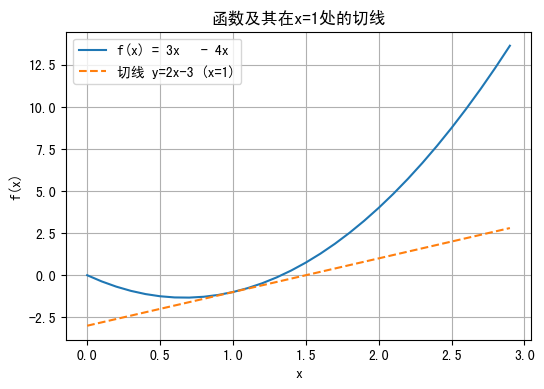

In [20]:
x = np.arange(0, 3, 0.1)
plt.figure(figsize=(6, 4))
plt.plot(x, f(x), label='f(x) = 3x² - 4x')
plt.plot(x, 2 * x - 3, linestyle='--', label='切线 y=2x-3 (x=1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.title('函数及其在x=1处的切线')
plt.show()

### 2.2 常用导数规则

- 常数: $DC = 0$
- 幂律: $Dx^n = nx^{n-1}$
- 指数: $De^x = e^x$
- 对数: $D\ln(x) = 1/x$

**运算法则**:
- 常数相乘: $\frac{d}{dx}[Cf(x)] = C\frac{d}{dx}f(x)$
- 加法: $\frac{d}{dx}[f(x) + g(x)] = \frac{d}{dx}f(x) + \frac{d}{dx}g(x)$
- 乘法: $\frac{d}{dx}[f(x)g(x)] = f(x)\frac{d}{dx}g(x) + g(x)\frac{d}{dx}f(x)$
- 除法: $\frac{d}{dx}\left[\frac{f(x)}{g(x)}\right] = \frac{g(x)\frac{d}{dx}f(x) - f(x)\frac{d}{dx}g(x)}{[g(x)]^2}$

### 2.3 偏导数与梯度

**偏导数**: 对多元函数,固定其他变量,对某一变量求导

$$\frac{\partial y}{\partial x_i} = \lim_{h \rightarrow 0} \frac{f(x_1, \ldots, x_i+h, \ldots, x_n) - f(x_1, \ldots, x_n)}{h}$$

**梯度**: 所有偏导数组成的向量

$$\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right]^\top$$

**常用梯度规则**:
- $\nabla_{\mathbf{x}} \mathbf{A}\mathbf{x} = \mathbf{A}^\top$
- $\nabla_{\mathbf{x}} \mathbf{x}^\top\mathbf{A} = \mathbf{A}$
- $\nabla_{\mathbf{x}} \|\mathbf{x}\|^2 = 2\mathbf{x}$

### 2.4 链式法则

用于复合函数求导,是反向传播算法的基础。

**单变量**: 若$y=f(u)$且$u=g(x)$,则
$$\frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}$$

**多变量**: 若$y$依赖于$u_1, \ldots, u_m$,每个$u_i$依赖于$x_1, \ldots, x_n$,则
$$\frac{\partial y}{\partial x_i} = \sum_{j=1}^{m} \frac{\partial y}{\partial u_j} \frac{\partial u_j}{\partial x_i}$$

---

## 第三部分: 概率论

### 3.1 基本概率论

In [21]:
import torch
from torch.distributions import multinomial

**示例: 投掷骰子**

In [22]:
# 公平骰子,每个面概率为1/6
fair_probs = torch.ones([6]) / 6
print("公平骰子的概率分布:", fair_probs)

# 抽取一个样本
sample = multinomial.Multinomial(1, fair_probs).sample()
print("\n单次投掷结果:", sample)

公平骰子的概率分布: tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667])

单次投掷结果: tensor([0., 0., 0., 0., 1., 0.])


**大数定律**: 随着试验次数增加,频率趋近于真实概率

In [23]:
# 投掷1000次
counts = multinomial.Multinomial(1000, fair_probs).sample()
print("投掷1000次的结果:")
print(counts)
print("\n相对频率(近似概率):")
print(counts / 1000)

投掷1000次的结果:
tensor([166., 203., 152., 170., 148., 161.])

相对频率(近似概率):
tensor([0.1660, 0.2030, 0.1520, 0.1700, 0.1480, 0.1610])


**可视化频率收敛**

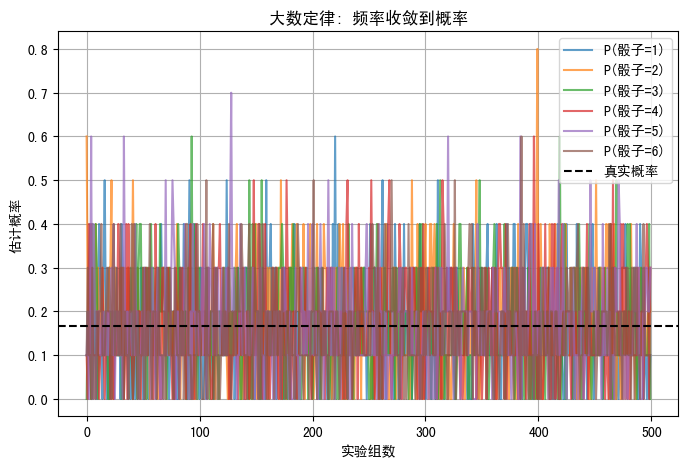

In [24]:
# 模拟多次实验
num_trials = 500
estimates = torch.zeros(num_trials, 6)

for i in range(num_trials):
    counts = multinomial.Multinomial(10, fair_probs).sample()
    estimates[i] = counts / 10

# 绘制每个面的概率估计
plt.figure(figsize=(8, 5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f'P(骰子={i+1})', alpha=0.7)
plt.axhline(y=1/6, color='black', linestyle='--', label='真实概率')
plt.xlabel('实验组数')
plt.ylabel('估计概率')
plt.legend()
plt.grid(True)
plt.title('大数定律: 频率收敛到概率')
plt.show()

### 3.2 随机变量与概率分布

**随机变量**: 在随机实验中可以取不同值的变量

- **离散随机变量**: 有限或可数个取值(如骰子点数)
- **连续随机变量**: 无限不可数个取值(如身高、体重)

### 3.3 处理多个随机变量

**联合概率**: $P(A=a, B=b)$ 表示$A=a$和$B=b$同时发生的概率

**条件概率**: $P(B=b \mid A=a) = \frac{P(A=a, B=b)}{P(A=a)}$

**贝叶斯定理**:
$$P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}$$

**边际化**(求和法则):
$$P(B) = \sum_{A} P(A, B)$$

**独立性**: 若$A$和$B$独立,则
$$P(A, B) = P(A)P(B)$$
$$P(A \mid B) = P(A)$$

**示例: 抛硬币**

In [25]:
# 模拟抛硬币(正面=1, 反面=0)
coin_probs = torch.tensor([0.5, 0.5])  # 公平硬币

# 抛10次硬币
num_tosses = 10
tosses = multinomial.Multinomial(num_tosses, coin_probs).sample()
print(f"抛{num_tosses}次硬币:")
print(f"正面: {int(tosses[1])}次")
print(f"反面: {int(tosses[0])}次")

抛10次硬币:
正面: 2次
反面: 8次


### 3.4 期望与方差

**期望**(均值): $E[X] = \sum_x x \cdot P(X=x)$

**方差**: $\text{Var}[X] = E[(X - E[X])^2] = E[X^2] - (E[X])^2$

**标准差**: $\sigma = \sqrt{\text{Var}[X]}$

In [26]:
# 生成服从标准正态分布的样本
samples = torch.randn(10000)

print("标准正态分布 N(0,1) 的样本统计:")
print(f"样本均值: {samples.mean():.4f} (理论值: 0)")
print(f"样本方差: {samples.var():.4f} (理论值: 1)")
print(f"样本标准差: {samples.std():.4f} (理论值: 1)")

标准正态分布 N(0,1) 的样本统计:
样本均值: -0.0063 (理论值: 0)
样本方差: 1.0199 (理论值: 1)
样本标准差: 1.0099 (理论值: 1)


**可视化正态分布**

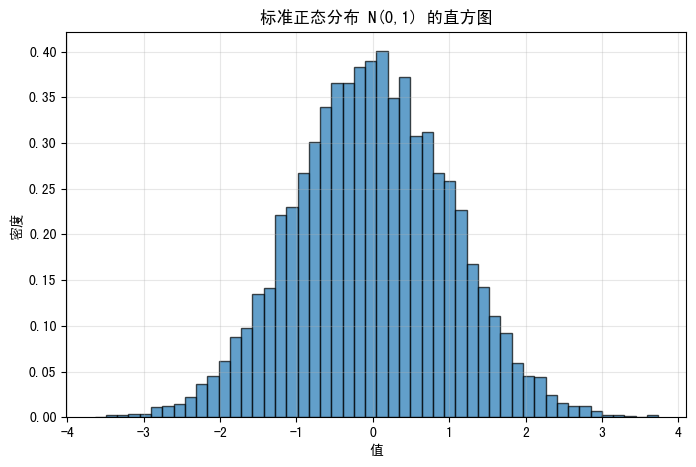

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(samples.numpy(), bins=50, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('值')
plt.ylabel('密度')
plt.title('标准正态分布 N(0,1) 的直方图')
plt.grid(True, alpha=0.3)
plt.show()

---

## 小结

### 线性代数
- **标量、向量、矩阵、张量**: 线性代数的基本对象
- **点积**: $\mathbf{x}^\top\mathbf{y}$,用于计算相似度和加权和
- **矩阵乘法**: 神经网络的核心运算
- **范数**: 衡量向量/矩阵大小,用于正则化和优化

### 微积分
- **导数**: 函数的瞬时变化率,切线斜率
- **梯度**: 多元函数的所有偏导数组成的向量
- **链式法则**: 复合函数求导,反向传播的数学基础

### 概率论
- **随机变量**: 可以取不同值的变量
- **概率分布**: 描述随机变量取各个值的可能性
- **联合概率、条件概率**: 处理多个随机变量
- **贝叶斯定理**: 概率推断的基础
- **期望与方差**: 描述分布的中心和离散程度

## 练习

### 线性代数
1. 证明矩阵转置的转置等于原矩阵: $(\mathbf{A}^\top)^\top = \mathbf{A}$
2. 给定方阵$\mathbf{A}$,证明$\mathbf{A} + \mathbf{A}^\top$总是对称的
3. 计算两个向量的夹角余弦值(提示: 使用点积和范数)

### 微积分
1. 绘制函数$y = x^3 - \frac{1}{x}$及其在$x=1$处的切线
2. 求函数$f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$的梯度
3. 使用链式法则求$\frac{d}{dx}\sin(x^2)$

### 概率论
1. 模拟抛100次硬币,计算正面出现的频率
2. 已知$P(A)=0.3$, $P(B)=0.4$, $P(A,B)=0.12$,判断$A$和$B$是否独立
3. 生成10000个样本,验证正态分布的68-95-99.7法则

## 练习题解答

In [34]:
#@title 计算两个向量的夹角余弦值
## 计算方法：cos_theta = (a . b) / ( ||a|| ||b|| )
# 即 两个向量的点积 除以 两个向量的模长 (L2 范数)

import torch

# 1. 定义两个向量
a = torch.tensor([1, 2, 3], dtype=float)
b = torch.tensor([4, 5, 6], dtype=float)

# 2. 计算点积（dot product）
dot_product = torch.dot(a, b)

# 3. 计算向量的范数 (Norm / 模长)
norm_a = torch.norm(a)
norm_b = torch.norm(b)

# 4. 计算余弦值
cos_theta = dot_product / (norm_a * norm_b)

print(f"向量 a: {a}")
print(f"向量 b: {b}")
print(f"夹角余弦值: {cos_theta.item():.4f}")



# 方法 2. 直接使用 Pytorch
import torch.nn.functional as F

# 注意：该函数期望输入是带 batch 维度的，所以用 unsqueeze(0) 增加一维
cos_sim = F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0))
print(f"Pytorch 内置函数计算结果: {cos_sim.item():.4f}")


向量 a: tensor([1., 2., 3.], dtype=torch.float64)
向量 b: tensor([4., 5., 6.], dtype=torch.float64)
夹角余弦值: 0.9746
Pytorch 内置函数计算结果: 0.9746


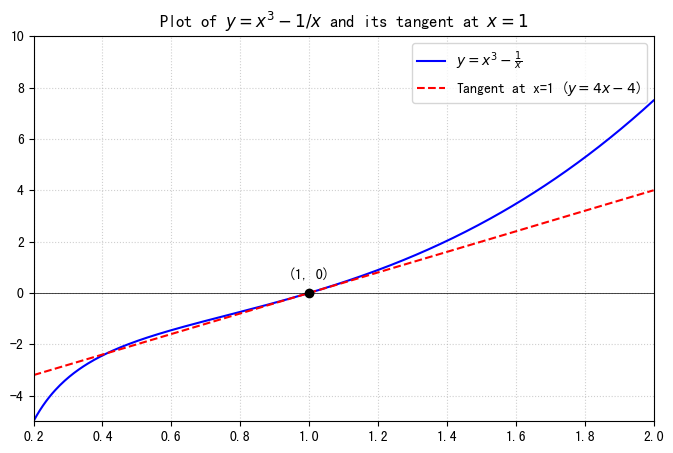

In [35]:
#@title 微积分 1. 绘制函数 y = x^3 - 1/x 的曲线 和 其在 x=1 处的切线
import numpy as np
import matplotlib.pyplot as plt

# 定义函数和切线
def f(x):
    return x**3 - 1/x

# 在 x=1 处的切线
def tangent(x):
    return 4*x - 4

# 生成数据点 (避开 x=0 的间断点)
x = np.linspace(0.2, 2, 400)
y = f(x)
y_tangent = tangent(x)

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y = x^3 - \frac{1}{x}$', color='blue')
plt.plot(x, y_tangent, label='Tangent at x=1 ($y=4x-4$)', linestyle='--', color='red')

# 标记切点 (1, 0)
plt.scatter([1], [0], color='black', zorder=5)
plt.annotate('(1, 0)', (1, 0), textcoords="offset points", xytext=(0,10), ha='center')

# 图表装饰
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.xlim(0.2, 2)
plt.ylim(-5, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title(r'Plot of $y = x^3 - 1/x$ and its tangent at $x=1$')
plt.show()


In [1]:
# 概率论
#@title 1. 模拟抛 100 次硬币并计算正面频率

import torch

# 模拟 100 次抛硬币 (0 代表反面, 1 代表正面)
# 使用 0.5 的概率生成 100 个随机数
tosses = torch.randint(0, 2, (100,))

# 计算正面（1）出现的次数和频率
heads_count = torch.sum(tosses).item()
frequency = heads_count / 100

print(f"正面出现次数: {heads_count}")
print(f"正面出现频率: {frequency:.2f}")


正面出现次数: 45
正面出现频率: 0.45


In [3]:
# 概率论
# @title 3. 验证正态分布的 68-95-99.7 法则 该法则指出，对于正态分布数据，约 68%、95% 和 99.7% 的数据分别落在距离均值 1、2 和 3 个标准差（\(\sigma \)）的范围内。

import torch

# 1. 生成 10000 个服从标准正态分布 (均值0, 标准差1) 的样本
samples = torch.randn(10000)

# 2. 计算各标准差范围内的比例
within_1std = (torch.abs(samples) <= 1).float().mean().item()
within_2std = (torch.abs(samples) <= 2).float().mean().item()
within_3std = (torch.abs(samples) <= 3).float().mean().item()

print(f"1个标准差内的样本比例: {within_1std*100:.2f}% (预期 ~68%)")
print(f"2个标准差内的样本比例: {within_2std*100:.2f}% (预期 ~95%)")
print(f"3个标准差内的样本比例: {within_3std*100:.2f}% (预期 ~99.7%)")

'''
运行说明：
1. torch.randn：直接生成均值为 0，标准差为 1 的正态分布数据。
2. torch.abs：通过取绝对值，可以快速判断样本是否落在 \([-\sigma ,\sigma ]\) 范围内。
'''

1个标准差内的样本比例: 68.64% (预期 ~68%)
2个标准差内的样本比例: 95.18% (预期 ~95%)
3个标准差内的样本比例: 99.77% (预期 ~99.7%)


<>:21: SyntaxWarning: invalid escape sequence '\('
<>:21: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-3522272242.py:21: SyntaxWarning: invalid escape sequence '\('
  2. torch.abs：通过取绝对值，可以快速判断样本是否落在 \([-\sigma ,\sigma ]\) 范围内。


'\n运行说明：\xa0\n1. torch.randn：直接生成均值为 0，标准差为 1 的正态分布数据。\n2. torch.abs：通过取绝对值，可以快速判断样本是否落在 \\([-\\sigma ,\\sigma ]\\) 范围内。\n'